# Mixture Model Fitting

We discuss the Gibbs sampler for fitting a †wo-component Gaussian mixture model. 

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm


For illustration, we shall use data on exoplanets. This dataset is downloaded from the NASA Exoplanet Archive. Some documentation describing each column, units and definitions is here: https://exoplanetarchive.ipac.caltech.edu/docs/API_PSCompPars_columns.html

In [4]:
df = pd.read_csv("exoplanet_data.csv")
print(df.shape)
print(df.head(10))

(6128, 5)
         pl_name   pl_radj  pl_bmassj  pl_orbper  st_teff
0  Kepler-1167 b  0.152556    0.01120   1.003934   4971.0
1  Kepler-1740 b  0.296478    0.03470   8.172400   5705.0
2  Kepler-1581 b  0.071371    0.00137   6.283855   6022.0
3   Kepler-644 b  0.281024    0.03170   3.173917   6747.0
4  Kepler-1752 b  0.405086    0.05900  56.358501   5446.0
5   Kepler-280 c  0.179000    0.01480   4.807091   5744.0
6  Kepler-1208 b  0.206977    0.01890  11.085076   5001.0
7   Kepler-263 c  0.220000    0.02100  47.332773   5265.0
8  Kepler-1101 b  0.220359    0.02100  81.315106   5614.0
9    HD 168746 b  0.993000    0.27000   6.404000   5570.0


We shall work with the planet radii column. This column gives radius of each exoplanet as a multiple of the radius of Jupyter.

In [ ]:
print(df["pl_radj"].notna().sum())
print(df.shape[0])

6078
6128


 There are a few NA values for the planet radius, so we will drop those. We will also work with the logarithms of the data. 

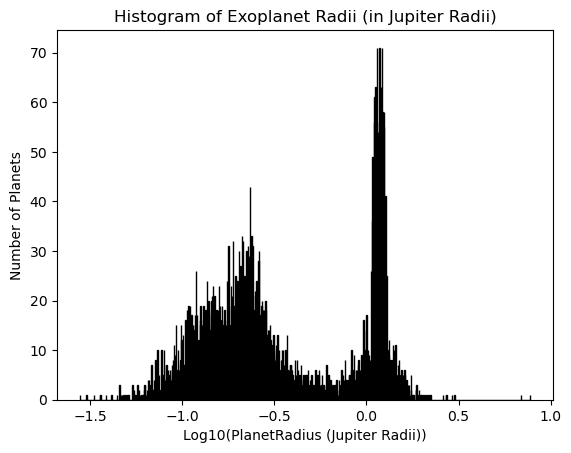

In [6]:
rad_full = df['pl_radj'].dropna()
lograd_full = np.log10(rad_full)
plt.hist(lograd_full, bins=1000, edgecolor='black')
plt.title('Histogram of Exoplanet Radii (in Jupiter Radii)')
plt.xlabel('Log10(PlanetRadius (Jupiter Radii))')
plt.ylabel('Number of Planets')
plt.show()

We shall fit the two-component Gaussian mixture model: 
\begin{align*}
   (1 - w) N(\mu_0, \sigma_0^2) + w N(\mu_1, \sigma_1^2)
\end{align*}
using both PyMC and the Gibbs sampler. The PyMC code is slow so let us work with a smaller dataset comprising about 10% of the data. 


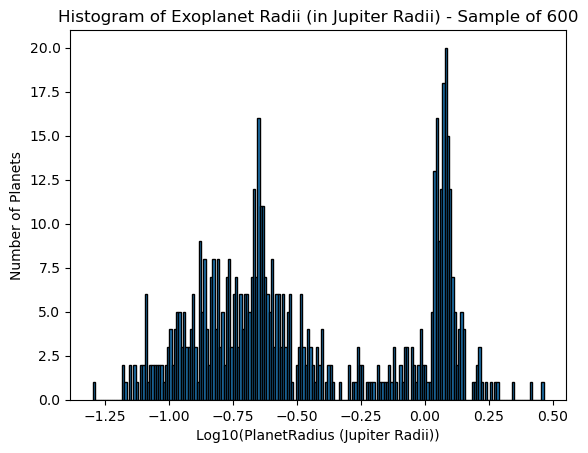

In [7]:
#Let us create a smaller dataset by taking n = 600 samples at random from the full dataset:
n = 600
lograd = lograd_full.sample(n, random_state=42) #random_state is for reproducibility
lograd = lograd.reset_index(drop=True) #reset the index after sampling
plt.hist(lograd, bins=200, edgecolor='black')
plt.title('Histogram of Exoplanet Radii (in Jupiter Radii) - Sample of 600')
plt.xlabel('Log10(PlanetRadius (Jupiter Radii))')
plt.ylabel('Number of Planets')
plt.show()

The unknown parameters in the model are $w, \mu_0, \mu_1, \sigma_0^2, \sigma_1^2$. We shall use the following priors: 
\begin{align*}
   w \sim \text{Beta}(1, 1) = \text{uniform}(0, 1)
\end{align*}
For $\mu_0, \mu_1$, we use $N(0, C)$ for a large $C$ (e.g., $C = 900$), and for $\sigma_0^2, \sigma_1^2$, we use $IG(0.01, 0.01)$. Recall that the $IG(\alpha, \beta)$ prior is $x^{-\alpha- 1} \exp(-\beta/x) I\{x > 0\}$ and when $\alpha = \beta = 0$, we get the $1/x$ prior which is the standard uninformative choice. So the choice $\alpha = \beta = 0.01$ is a proper approximation of the standard uninformative prior. 

Let us first fit this mixture model via PyMC. 

In [10]:
#Let us fit a two-component Gaussian mixture model to the log-radii data. We will use PyMC for this.
N = len(lograd)
exoplanet_model = pm.Model()
with exoplanet_model:
    w = pm.Beta('w', alpha = 1, beta = 1)
    mus = pm.Normal('mus', mu = np.array([0.0, 0.0]), sigma = 30, shape = 2)
    sigma2 = pm.InverseGamma('sigma2', alpha = 0.01, beta = 0.01, shape = 2) #the InverseGamma is a distribution over positive real numbers, and is often used as a prior for variances
    sigmas = pm.Deterministic('sigmas', np.sqrt(sigma2))
    category = pm.Bernoulli('category', p = w, shape = N)
    mean_individual = mus[category]
    sd_individual = sigmas[category]
    obs = pm.Normal('obs', mu = mean_individual, sigma = sd_individual, observed = lograd)
    idata = pm.sample(2000, chains = 1, return_inferencedata = True, random_seed = 4)



Sequential sampling (1 chains in 1 job)
CompoundStep
>NUTS: [w, mus, sigma2]
>BinaryGibbsMetropolis: [category]


/Users/aditya/mambaforge/envs/stat238spring2026/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 78 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


The posterior samples generated by PyMC are obtained as follows, together with posterior means. 

In [12]:
w_samples = idata.posterior['w'].values.flatten()
wmean = np.mean(w_samples)

mus_samples = idata.posterior['mus'].values
combined_mus_samples = mus_samples.reshape(-1, 2)
mus_means = np.mean(combined_mus_samples, axis=0)

sigmas_samples = idata.posterior['sigmas'].values
combined_sigmas_samples = sigmas_samples.reshape(-1, 2)
sigmas_means = np.mean(combined_sigmas_samples, axis=0)

print(f"mean of w: {wmean}")
print(f"mean of mu_0: {mus_means[0]}")
print(f"mean of mu_1: {mus_means[1]}")
print(f"mean of sigma_0: {sigmas_means[0]}")
print(f"mean of sigma_1: {sigmas_means[1]}")

mean of w: 0.33158388246022946
mean of mu_0: -0.7155163498787434
mean of mu_1: 0.06486691270349927
mean of sigma_0: 0.2145293354629911
mean of sigma_1: 0.09151852868941668


The estimate of $w$ is 0.33, which means that more exoplanets belong to the first group $N(\mu_0, \sigma_0^2)$ (compared to the second group $N(\mu_1, \sigma_1^2)$). The trace plots for each of the parameters can be obtained as follows. 

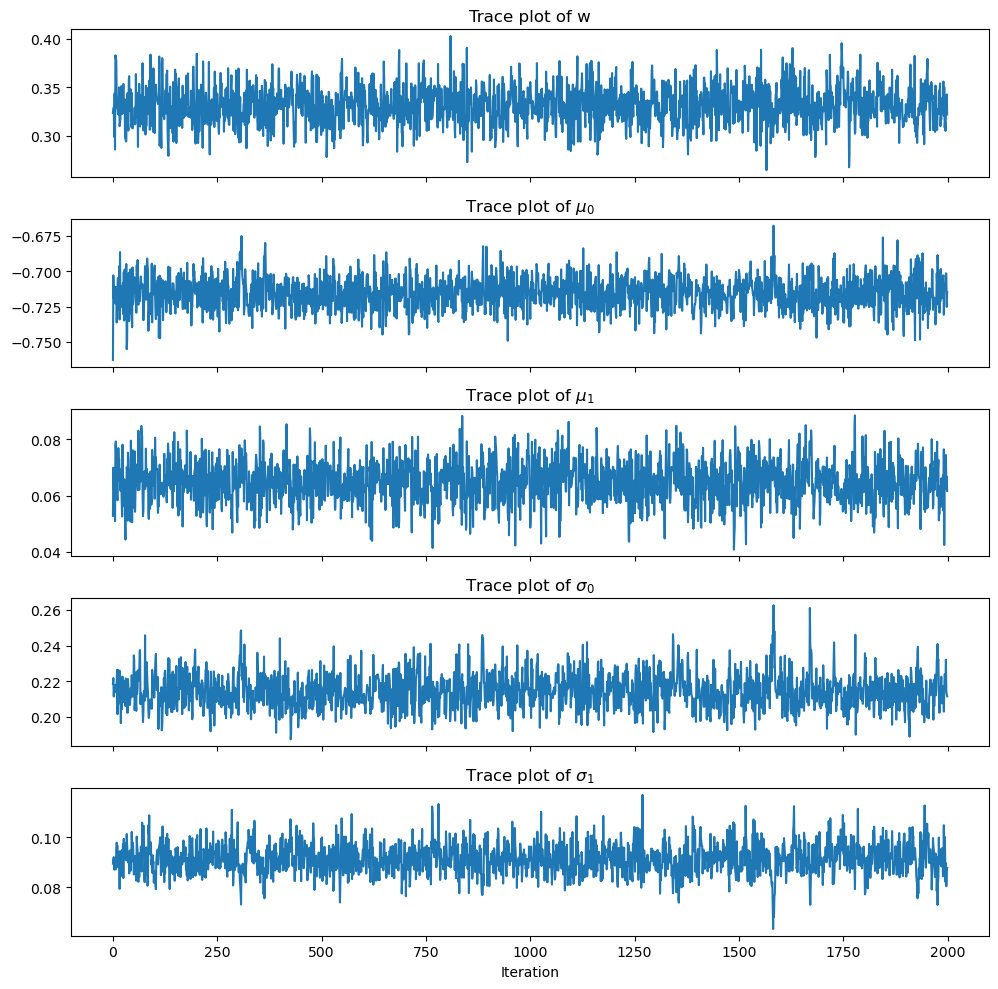

In [13]:
fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)

axes[0].plot(w_samples)
axes[0].set_title("Trace plot of w")

axes[1].plot(combined_mus_samples[:, 0])
axes[1].set_title(r"Trace plot of $\mu_0$")

axes[2].plot(combined_mus_samples[:, 1])
axes[2].set_title(r"Trace plot of $\mu_1$")

axes[3].plot(combined_sigmas_samples[:, 0])
axes[3].set_title(r"Trace plot of $\sigma_0$")

axes[4].plot(combined_sigmas_samples[:, 1])
axes[4].set_title(r"Trace plot of $\sigma_1$")
axes[4].set_xlabel("Iteration")

plt.tight_layout()
plt.show()

The trace plots above show that the PyMC Markov Chain has mixed well. Below we plot the fitted density (with parameter values taken to be their posterior means) on the histogram of the data. 

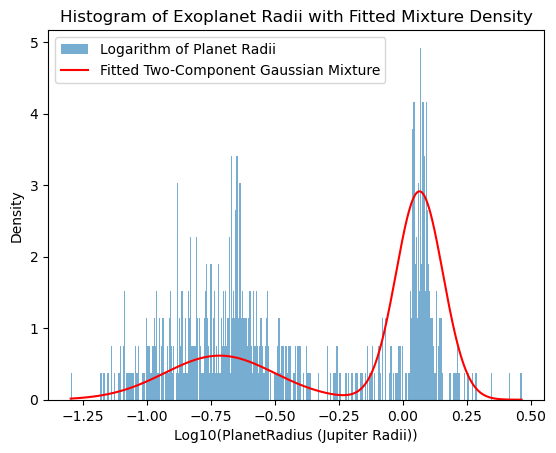

In [15]:
#Plotting the fitted two component normal mixture density on the histogram
from scipy.stats import norm

plt.hist(lograd, bins = 400, density = True, alpha = 0.6, label = 'Logarithm of Planet Radii')
x = np.linspace(lograd.min(), lograd.max(), 1000)
pdf = wmean * norm.pdf(x, loc=mus_means[0], scale=sigmas_means[0]) + (1 - wmean) * norm.pdf(x, loc=mus_means[1], scale=sigmas_means[1])
plt.plot(x, pdf, color='red', label='Fitted Two-Component Gaussian Mixture')
plt.title('Histogram of Exoplanet Radii with Fitted Mixture Density')
plt.xlabel('Log10(PlanetRadius (Jupiter Radii))')
plt.ylabel('Density')
plt.legend()
plt.show()

Even though the fit is decent, the normal density does not seem to capture the two peaks well. For the $i$-th exoplanet, $z_i$ denotes the indicator variable that the exoplanet belongs to the second group. The posterior mean of $z_i$ is the posterior probability that the $i$-th exoplanet belongs to the second group. Below is a histogram of the posterior means of $z_1, \dots, z_n$. 

(2000, 600)


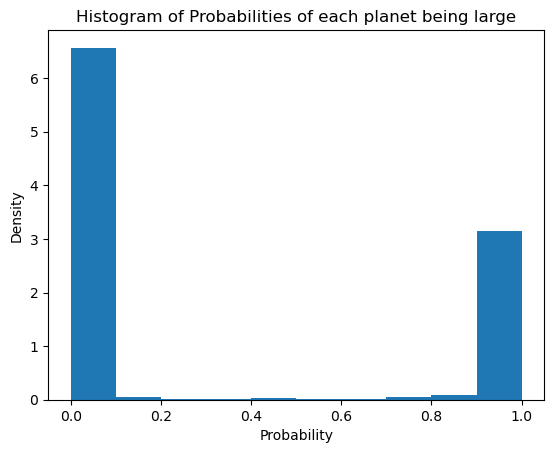

In [17]:
category_samples = idata.posterior['category'].values
combined_samples = category_samples.reshape(-1, N)
print(combined_samples.shape)
category_means = np.mean(combined_samples, axis = 0)

plt.hist(category_means, density = True)
plt.title('Histogram of Probabilities of each planet being large')
plt.xlabel('Probability')
plt.ylabel('Density')
plt.show()

Now let us implement the Gibbs sampler to fit this mixture model. The Gibbs sampler code is given below. 

In [20]:
from scipy.special import logsumexp

def gibbs_gmm(lograd, n_iter=10000,
              alpha_w=1, beta_w=1,
              mu_prior=np.array([0.0, 0.0]),
              tau_prior=np.array([30.0, 30.0]),
              a_sigma=0.01, b_sigma=0.01,
              random_seed=None):

    rng = np.random.default_rng(random_seed)
    y = np.asarray(lograd)
    N = len(y)

    mus = mu_prior.copy()
    sigmas = np.array([2.0, 2.0]) #initial values for sigma_0, sigma_1
    w = alpha_w / (alpha_w + beta_w)

    z = rng.binomial(1, w, size=N)

    w_samples, mus_samples, sigmas_samples, z_samples = [], [], [], []

    for it in range(n_iter):
        logp0 = np.log(1 - w + 1e-16) - 0.5*np.log(2*np.pi*sigmas[0]**2) - 0.5*(y - mus[0])**2/sigmas[0]**2
        logp1 = np.log(w + 1e-16)     - 0.5*np.log(2*np.pi*sigmas[1]**2) - 0.5*(y - mus[1])**2/sigmas[1]**2
        p1 = np.exp(logp1 - logsumexp(np.vstack([logp0, logp1]), axis=0))
        z = rng.binomial(1, p1)

        n1 = z.sum()
        w = rng.beta(alpha_w + n1, beta_w + N - n1)

        for k in [0, 1]:
            yk = y[z == k]
            nk = len(yk)
            s2 = sigmas[k]**2
            tau2 = tau_prior[k]**2

            post_var = 1 / (1/tau2 + nk/s2)
            post_mean = post_var * (mu_prior[k]/tau2 + yk.sum()/s2)
            mus[k] = rng.normal(post_mean, np.sqrt(post_var))

            shape = a_sigma + nk/2
            scale = b_sigma + 0.5*np.sum((yk - mus[k])**2)
            s2_new = 1 / rng.gamma(shape, scale=1/scale)
            sigmas[k] = np.sqrt(s2_new)

        w_samples.append(w)
        mus_samples.append(mus.copy())
        sigmas_samples.append(sigmas.copy())
        z_samples.append(z.copy())

    return {
        "w": np.array(w_samples),
        "mus": np.array(mus_samples),
        "sigmas": np.array(sigmas_samples),
        "z": np.array(z_samples),
    }

This Gibbs sampler function takes much less time to run compared to PyMC (even to obtain a much larger sample). 

In [22]:
samples_full = gibbs_gmm(lograd, n_iter=40000, random_seed=4)
burnin = 2000
samples = {k: v[burnin:] for k, v in samples_full.items()}

The trace plots of the parameters are given below. 

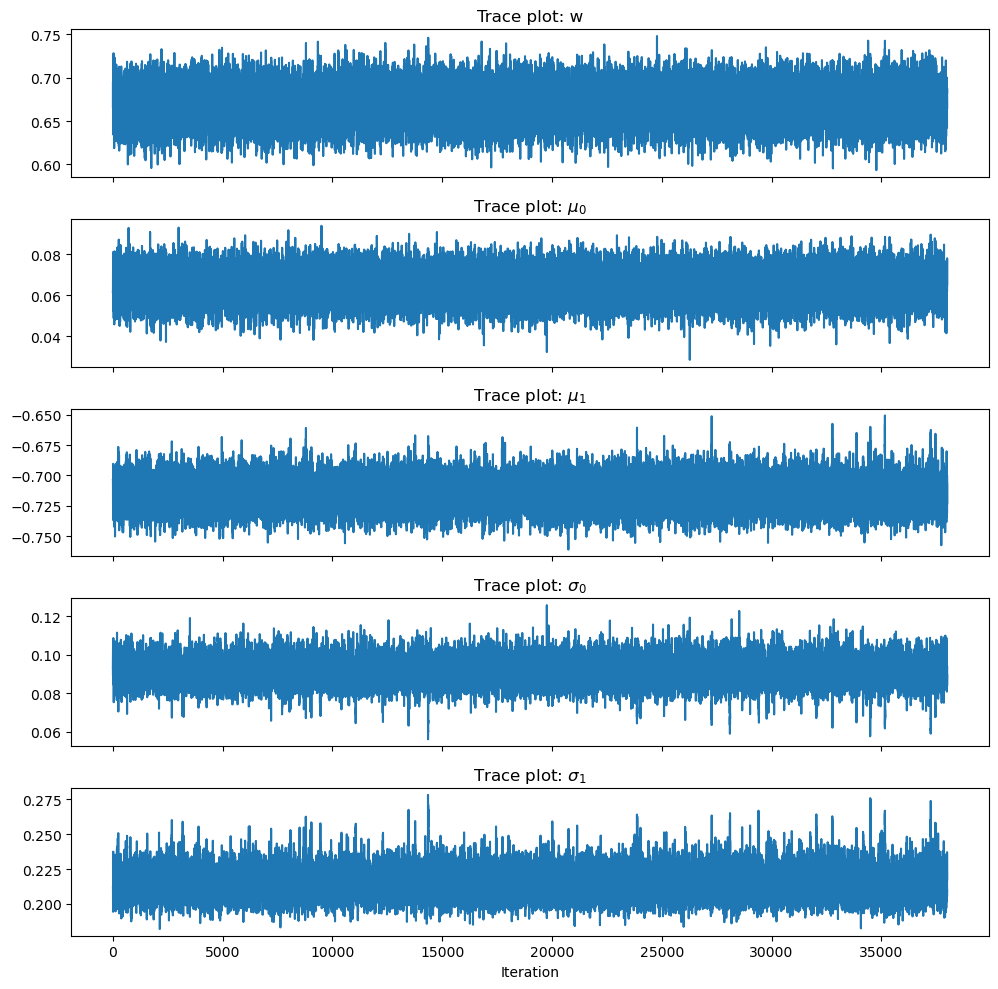

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)

axes[0].plot(samples["w"])
axes[0].set_title("Trace plot: w")

axes[1].plot(samples["mus"][:, 0])
axes[1].set_title(r"Trace plot: $\mu_0$")

axes[2].plot(samples["mus"][:, 1])
axes[2].set_title(r"Trace plot: $\mu_1$")

axes[3].plot(samples["sigmas"][:, 0])
axes[3].set_title(r"Trace plot: $\sigma_0$")

axes[4].plot(samples["sigmas"][:, 1])
axes[4].set_title(r"Trace plot: $\sigma_1$")

axes[4].set_xlabel("Iteration")
plt.tight_layout()
plt.show()

Here are the posterior means. 

In [24]:
print("Posterior mean of w:", samples["w"].mean())
print("Posterior mean of mu_0 and mu_1:", samples["mus"].mean(axis=0))
print("Posterior mean of sigma_0 and sigma_1:", samples["sigmas"].mean(axis=0))

Posterior mean of w: 0.669557319138589
Posterior mean of mu_0 and mu_1: [ 0.06500875 -0.7147984 ]
Posterior mean of sigma_0 and sigma_1: [0.09093584 0.21508265]


The posterior mean of $w$ is now 0.67, while the PyMC code gave the posterior mean of $w$ to be 0.33. This means that label switching has occurred. The estimates of $w, \mu_0, \mu_1, \sigma_0^2, \sigma_1^2$ given by PyMC now coincide with those of $1-w, \mu_1, \mu_0, \sigma_1^2, \sigma_0^2$ given by the Gibbs sampler code. Despite this mismatch, the fitted densities are identical as shown below. 

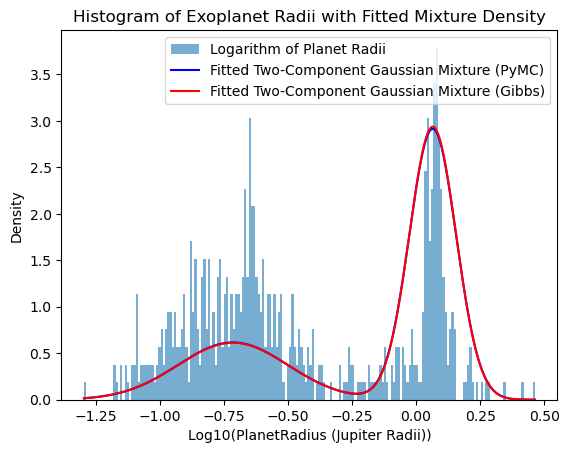

In [26]:
#Plotting the fitted two component normal mixture density on the histogram
from scipy.stats import norm

plt.hist(lograd, bins = 200, density = True, alpha = 0.6, label = 'Logarithm of Planet Radii')
x = np.linspace(lograd.min(), lograd.max(), 1000)
pdf_pymc = wmean * norm.pdf(x, loc=mus_means[0], scale=sigmas_means[0]) + (1 - wmean) * norm.pdf(x, loc=mus_means[1], scale=sigmas_means[1])
pdf_gibbs = samples["w"].mean() * norm.pdf(x, loc=samples["mus"].mean(axis=0)[0], scale=samples["sigmas"].mean(axis=0)[0]) + (1 - samples["w"].mean()) * norm.pdf(x, loc=samples["mus"].mean(axis=0)[1], scale=samples["sigmas"].mean(axis=0)[1])
plt.plot(x, pdf_pymc, color='blue', label='Fitted Two-Component Gaussian Mixture (PyMC)')
plt.plot(x, pdf_gibbs, color='red', label='Fitted Two-Component Gaussian Mixture (Gibbs)')
plt.title('Histogram of Exoplanet Radii with Fitted Mixture Density')
plt.xlabel('Log10(PlanetRadius (Jupiter Radii))')
plt.ylabel('Density')
plt.legend()
plt.show()

One advantage of the Gibbs sampler is that it can be implemented on the whole dataset (of size around 6K). In contrast, PyMC takes a really long time to run on the whole data. 

In [27]:
#Gibbs sampler on the full dataset:
samples_full_wholedata = gibbs_gmm(lograd_full, n_iter=40000, random_seed=123)
burnin = 2000
samples_wholedata = {k: v[burnin:] for k, v in samples_full_wholedata.items()}

The estimates and fitted density now (on the whole dataset) are plotted below. 

In [28]:
print("Posterior mean of w:", samples_wholedata["w"].mean())
print("Posterior mean of mu_0 and mu_1:", samples_wholedata["mus"].mean(axis=0))
print("Posterior mean of sigma_0 and sigma_1:", samples_wholedata["sigmas"].mean(axis=0))

Posterior mean of w: 0.693331696753807
Posterior mean of mu_0 and mu_1: [ 0.06554884 -0.70760319]
Posterior mean of sigma_0 and sigma_1: [0.06801815 0.22948966]


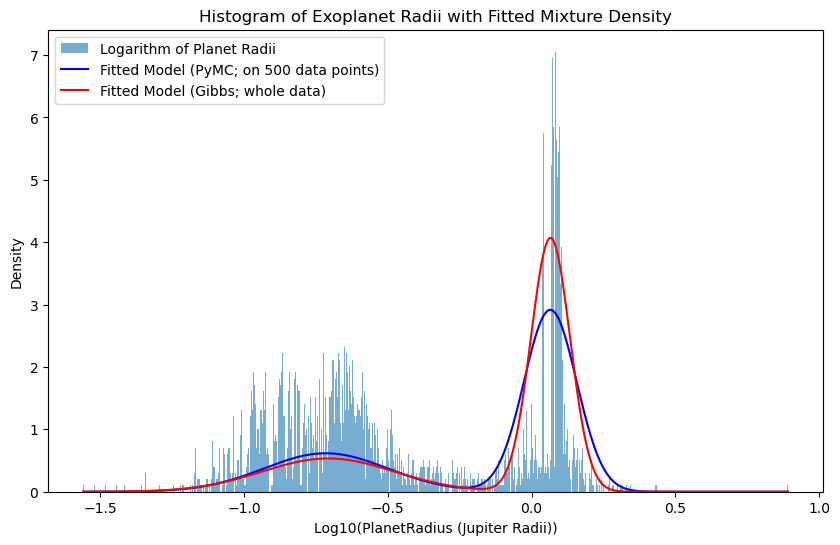

In [30]:
#Plotting the fitted two component normal mixture density on the histogram
from scipy.stats import norm
plt.figure(figsize=(10, 6))
plt.hist(lograd_full, bins = 1500, density = True, alpha = 0.6, label = 'Logarithm of Planet Radii')
x = np.linspace(lograd_full.min(), lograd_full.max(), 1000)
pdf_pymc = wmean * norm.pdf(x, loc=mus_means[0], scale=sigmas_means[0]) + (1 - wmean) * norm.pdf(x, loc=mus_means[1], scale=sigmas_means[1])
pdf_gibbs_whole = samples_wholedata["w"].mean() * norm.pdf(x, loc=samples_wholedata["mus"].mean(axis=0)[0], scale=samples_wholedata["sigmas"].mean(axis=0)[0]) + (1 - samples_wholedata["w"].mean()) * norm.pdf(x, loc=samples_wholedata["mus"].mean(axis=0)[1], scale=samples_wholedata["sigmas"].mean(axis=0)[1])
plt.plot(x, pdf_pymc, color='blue', label='Fitted Model (PyMC; on 500 data points)')
plt.plot(x, pdf_gibbs_whole, color='red', label='Fitted Model (Gibbs; whole data)')
plt.title('Histogram of Exoplanet Radii with Fitted Mixture Density')
plt.xlabel('Log10(PlanetRadius (Jupiter Radii))')
plt.ylabel('Density')
plt.legend()
plt.show()

The fitted density is now different (with the $\sigma$ corresponding to the second group being smaller) compared to the fitted density on the smaller dataset. 